<a href="https://colab.research.google.com/github/Maryam-71295/iris-data-analysis-datascience-internship-task1/blob/main/Iris_Eda_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# **Problem Definition and Dataset Preview¶**
This dataset comprises 150 samples across 3 iris species (Iris-setosa, Iris-versicolor, Iris-virginica) with 50 samples per species. Each sample has 4 continuous features: SepalLengthCm, SepalWidthCm, PetalLengthCm, and PetalWidthCm. The goal is to build a classification model to accurately predict iris species based on these floral measurements.

In [3]:
df = pd.read_csv("/content/Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [21]:
# 1. Checking for missing values
print("Missing Value Counts:")
print(df.isnull().sum())
print("-" * 30)

Missing Value Counts:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
------------------------------


In [5]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [6]:
df["Species"].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [7]:
df.shape

(150, 6)

# Data Visualization

<Axes: xlabel='SepalLengthCm', ylabel='SepalWidthCm'>

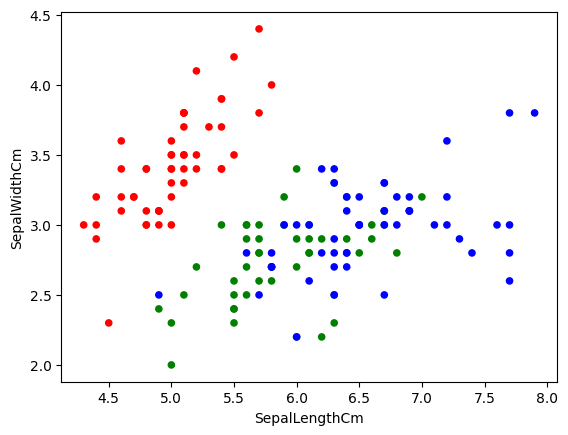

In [11]:
# Color mapping for species in the scatter plot
color_map = {
    "Iris-setosa": "red",
    "Iris-versicolor": "green",
    "Iris-virginica": "blue",
}

# Example: Scatter plot of Sepal Length vs Sepal Width colored by species
df.plot(kind="scatter", x="SepalLengthCm", y="SepalWidthCm", c=df["Species"].map(color_map))

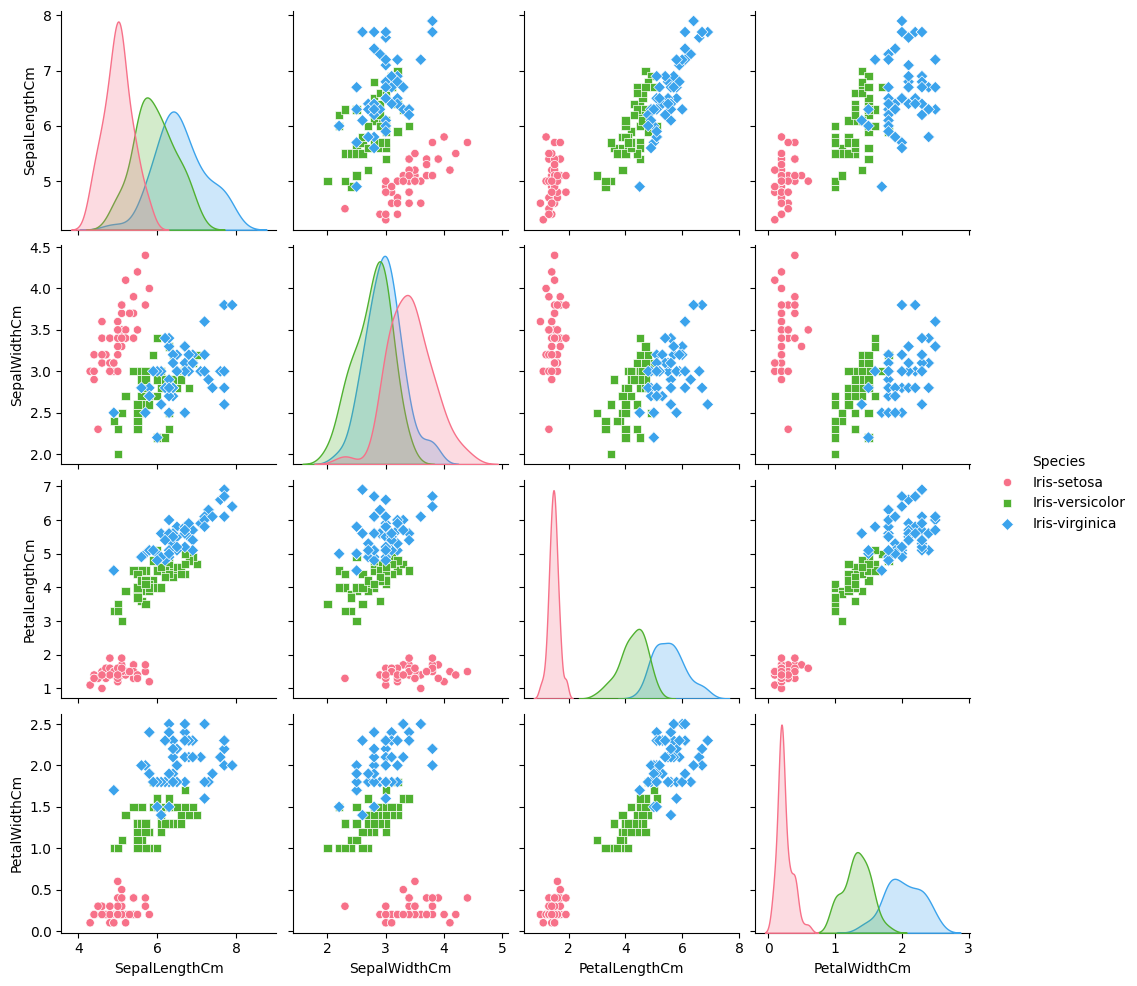

In [22]:
# Since the 'Id' column is just a sequence number, it won't be useful for analysis.
# We are creating a new variable by dropping it to exclude it from the plots.
df_visual = df.drop('Id', axis=1)

# Plotting the distribution and relationships of all features grouped by species
sns.pairplot(df_visual, hue="Species", palette="husl", markers=["o", "s", "D"])

# Display the plot
plt.show()

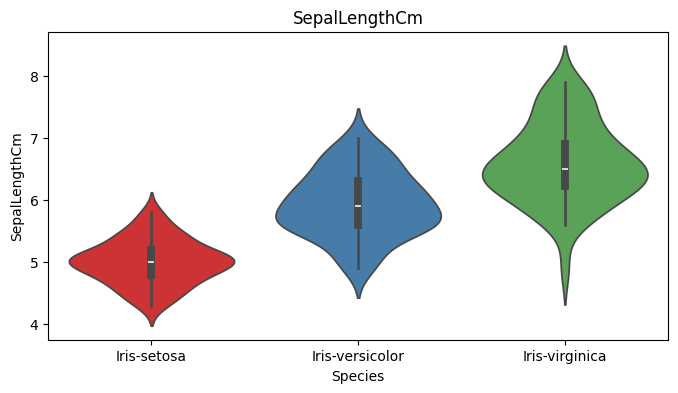

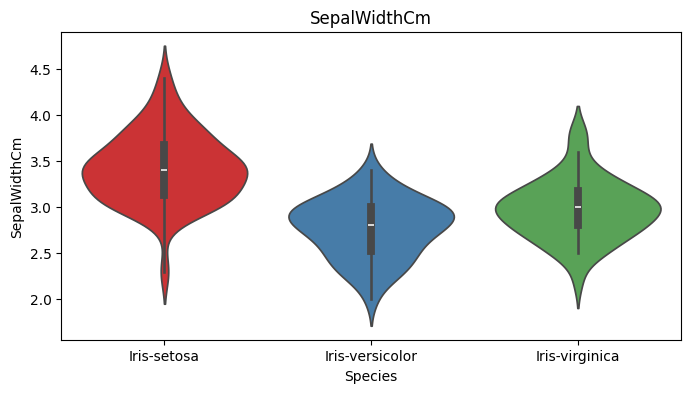

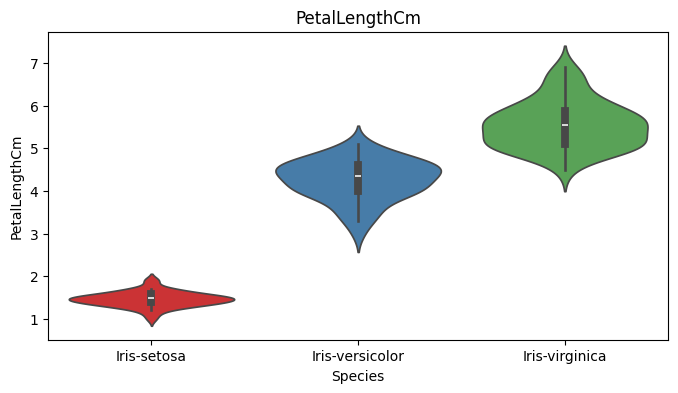

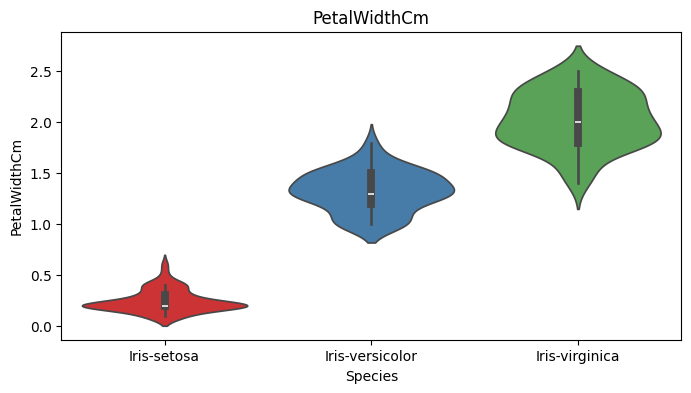

In [12]:
# Violin plots to visualize distribution shapes and densities
for column in ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]:
    plt.figure(figsize=(8, 4))
    sns.violinplot(x="Species", y=column, hue="Species", data=df, palette="Set1")
    plt.title(f"{column}")
    plt.xlabel("Species")
    plt.ylabel(column)
    plt.show()

Text(0.5, 1.0, 'Feature Correlation Heatmap')

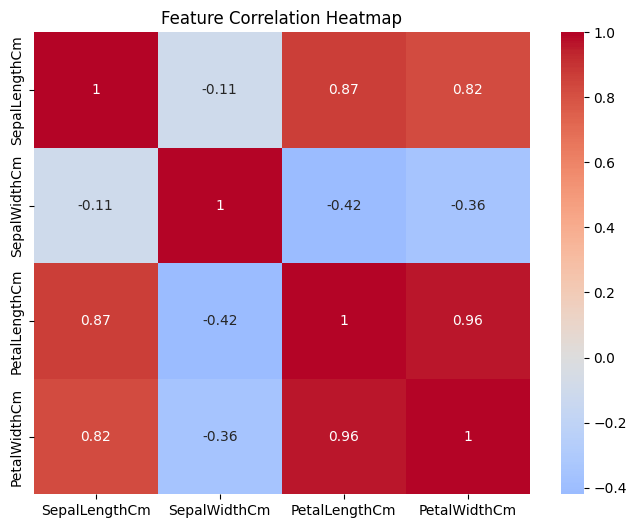

In [14]:
# Correlation heatmap to visualize relationships between features

plt.figure(figsize=(8,6))
sns.heatmap(df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]].corr(),
            annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")

In [15]:
# Dropping 'Id', 'SepalLengthCm', and 'PetalWidthCm' to create a reduced feature set for classification

iris_reduced = df.copy()
iris_reduced.drop(['Id','SepalLengthCm','PetalWidthCm'], axis=1, inplace=True)

In [16]:
#Label Encoding the target variable 'Species'

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
iris_reduced["Species"] = le.fit_transform(iris_reduced["Species"])
iris_reduced.head()

,SepalWidthCm,PetalLengthCm,Species
0,3.5,1.4,0
1,3.0,1.4,0
2,3.2,1.3,0
3,3.1,1.5,0
4,3.6,1.4,0


In [17]:
# Apply standard scaling to the reduced feature set

from sklearn.preprocessing import StandardScaler
X_reduced = iris_reduced.drop("Species", axis=1)
y_reduced = iris_reduced["Species"]
scaler = StandardScaler()
Xr_scaled = scaler.fit_transform(X_reduced)
Xr_scaled = pd.DataFrame(Xr_scaled, columns=X_reduced.columns)
Xr_scaled.head()

,SepalWidthCm,PetalLengthCm
0,1.032057,-1.341272
1,-0.124958,-1.341272
2,0.337848,-1.398138
3,0.106445,-1.284407
4,1.263460,-1.341272


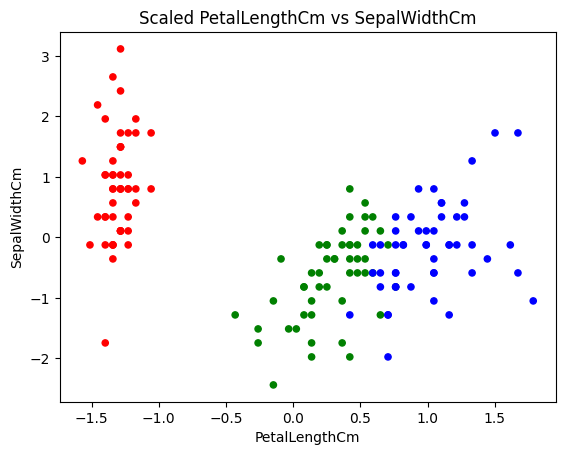

In [19]:
%matplotlib inline
Xr_scaled.plot(kind="scatter",x="PetalLengthCm",y="SepalWidthCm",c=df["Species"].map(color_map))
plt.title("Scaled PetalLengthCm vs SepalWidthCm")
plt.show()

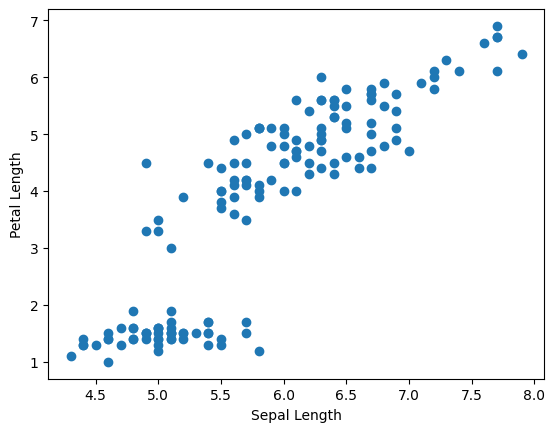

In [23]:
plt.scatter(df['SepalLengthCm'],df['PetalLengthCm'])
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.show()

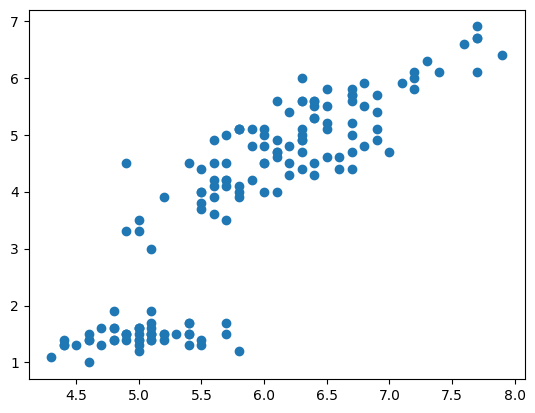

In [28]:
plt.scatter(df['SepalLengthCm'],df['PetalLengthCm'])
plt.show()

Text(0.5, 0, 'SepalLengthCm')

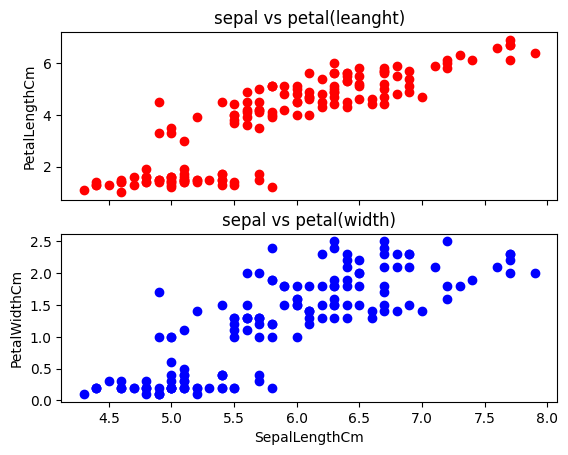

In [29]:
fig,ax = plt.subplots(nrows=2,ncols=1,sharex=True)
ax[0].scatter(df['SepalLengthCm'],df['PetalLengthCm'],color='red')
ax[1].scatter(df['SepalLengthCm'],df['PetalWidthCm'],color='blue')
ax[0].set_title('sepal vs petal(leanght)')
ax[1].set_title('sepal vs petal(width)')

ax[0].set_ylabel('PetalLengthCm')
ax[1].set_ylabel('PetalWidthCm')

ax[1].set_xlabel('SepalLengthCm')
# here we change the title as set_title , label as set_label etc.
# despite  using ax as array you can use add_subplot fun

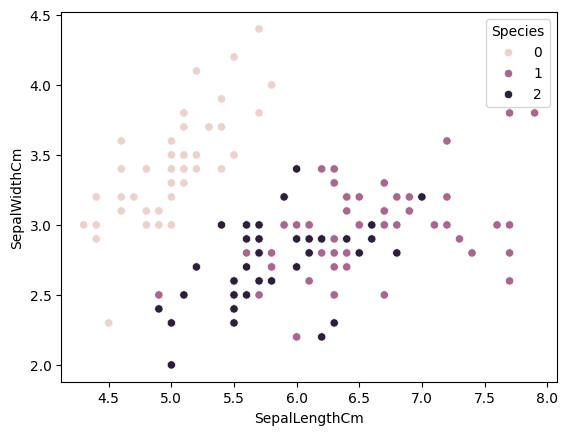

In [30]:
sns.scatterplot(x = df["SepalLengthCm"], y = df["SepalWidthCm"], hue = df["Species"])
plt.show()

<Axes: xlabel='SepalLengthCm', ylabel='SepalWidthCm'>

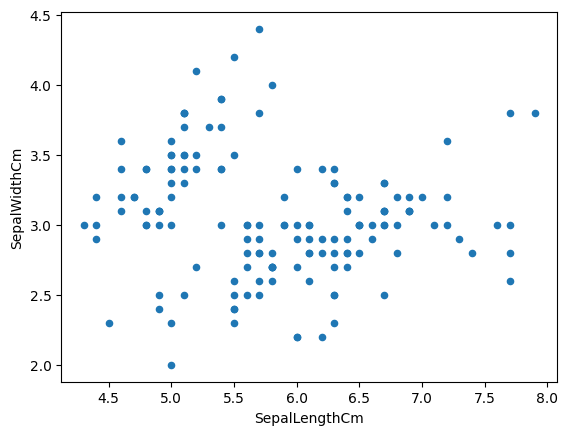

In [34]:
# The first way we can plot things is using the .plot extension from Pandas dataframes
# We'll use this to make a scatterplot of the Iris features.
df.plot(kind="scatter", x="SepalLengthCm", y="SepalWidthCm")

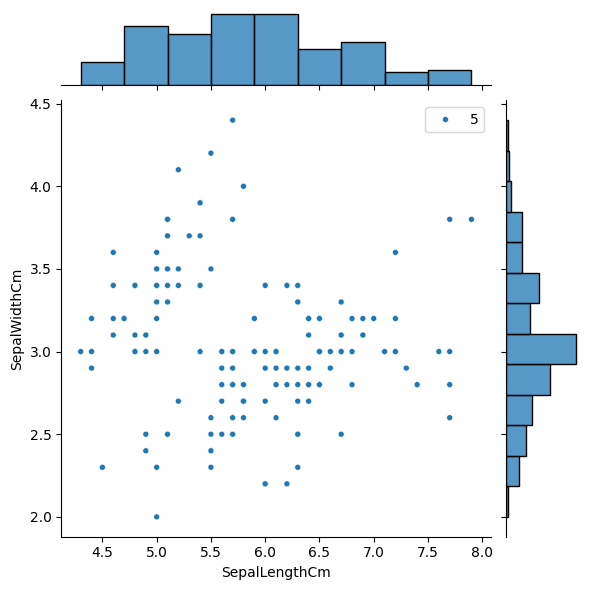

In [35]:
# We can also use the seaborn library to make a similar plot
# A seaborn jointplot shows bivariate scatterplots and univariate histograms in the same figure
sns.jointplot(x="SepalLengthCm", y="SepalWidthCm", data=df, size=5)

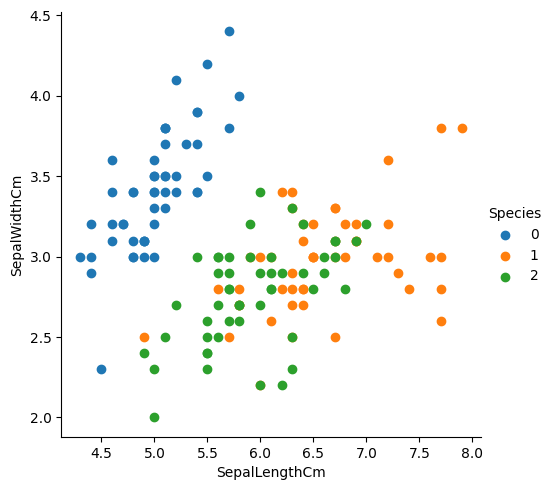

In [36]:
# One piece of information missing in the plots above is what species each plant is
# We'll use seaborn's FacetGrid to color the scatterplot by species
sns.FacetGrid(df, hue="Species", height=5) \
   .map(plt.scatter, "SepalLengthCm", "SepalWidthCm") \
   .add_legend()

# Earlier: sns.FacetGrid(iris, hue="Species", size=5)

<Axes: xlabel='Species', ylabel='PetalLengthCm'>

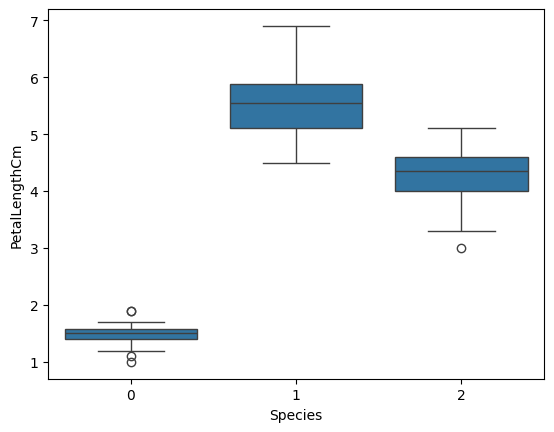

In [31]:
# We can look at an individual feature in Seaborn through a boxplot
sns.boxplot(x="Species", y="PetalLengthCm", data=df)

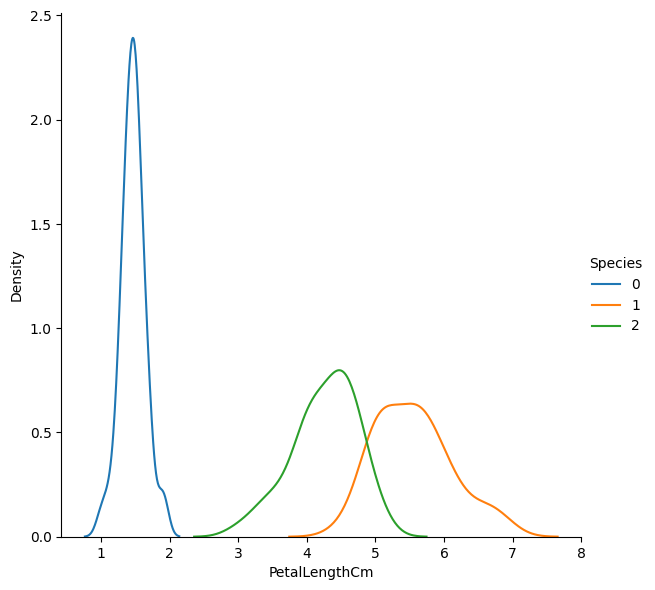

In [32]:
# A final seaborn plot useful for looking at univariate relations is the kdeplot,
# which creates and visualizes a kernel density estimate of the underlying feature
sns.FacetGrid(df, hue="Species", height=6) \
   .map(sns.kdeplot, "PetalLengthCm") \
   .add_legend()

<Axes: >

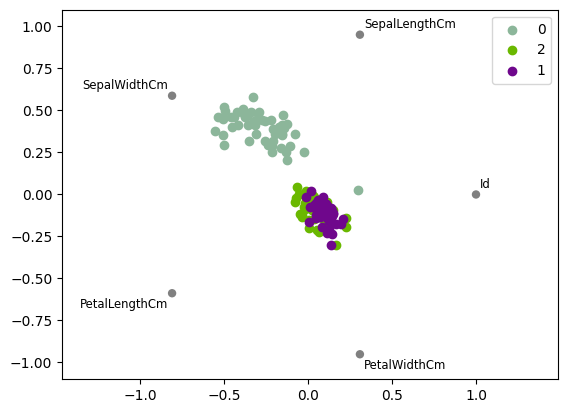

In [38]:
# A final multivariate visualization technique pandas has is radviz
# Which puts each feature as a point on a 2D plane, and then simulates
# having each sample attached to those points through a spring weighted
# by the relative value for that feature
from pandas.plotting import radviz
radviz(df, "Species")